## Imports necessários

In [ ]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

## Carregando as bases de dados

In [ ]:
# Local das bases no drive
PASTA_COMPARTILHADA = "Validacao_dados_clima/analises"
RAIZ_DRIVE = f"/content/drive/MyDrive/{PASTA_COMPARTILHADA}"

try:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print(f"Aviso: Google Drive indisponível ({e}). "
          f"Rode este notebook no Google Colab.")

if not os.path.isdir(RAIZ_DRIVE):
    raise FileNotFoundError(
        f"Não encontrei '{PASTA_COMPARTILHADA}' em 'Meu Drive'. "
        f"Crie um ATALHO da pasta compartilhada para o seu 'Meu Drive' "
        f"e rode esta célula de novo."
    )

print(f"Raiz no Drive: {RAIZ_DRIVE}")
print()
print("Subpastas encontradas:")
for nome in sorted(os.listdir(RAIZ_DRIVE)):
    caminho = os.path.join(RAIZ_DRIVE, nome)
    if os.path.isdir(caminho):
        n_csv = len(glob.glob(os.path.join(caminho, "*.csv")))
        print(f"  - {nome}/   ({n_csv} arquivo(s) .csv)")


Mounted at /content/drive
Raiz no Drive: /content/drive/MyDrive/Validacao_dados_clima/analises

Subpastas encontradas:
  - dados mensais das estações/   (23 arquivo(s) .csv)
  - dados_chelsa/   (1 arquivo(s) .csv)
  - dados_terraclimate/   (1 arquivo(s) .csv)
  - dados_xavier/   (1 arquivo(s) .csv)


In [ ]:
SUBPASTAS_BASES = {
    # base gerada por você (1 CSV por estação, agregado mensal)
    "estacoes":        "dados mensais das estações",
    # bases de referência para a comparação (1 CSV cada)
    "xavier":       "dados_xavier",
    "chelsa":       "dados_chelsa",
    "terraclimate": "dados_terraclimate",
}

# Validação: avisa se alguma subpasta não existe
for apelido, sub in SUBPASTAS_BASES.items():
    caminho = os.path.join(RAIZ_DRIVE, sub)
    status = "OK" if os.path.isdir(caminho) else "NÃO ENCONTRADA"
    print(f"  [{status}] {apelido:<10} -> {sub}")

print()
print("Edite SUBPASTAS_BASES com os nomes reais das subpastas das bases "
      "que você quer comparar, depois rode a próxima célula.")

  [OK] estacoes   -> dados mensais das estações
  [OK] xavier     -> dados_xavier
  [OK] chelsa     -> dados_chelsa
  [OK] terraclimate -> dados_terraclimate

Edite SUBPASTAS_BASES com os nomes reais das subpastas das bases que você quer comparar, depois rode a próxima célula.


In [ ]:
def carregar_base(apelido, subpasta):
    pasta = os.path.join(RAIZ_DRIVE, subpasta)
    arquivos = sorted(glob.glob(os.path.join(pasta, "*.csv")))
    dfs = {}
    for arq in arquivos:
        chave = os.path.splitext(os.path.basename(arq))[0]
        try:
            df = pd.read_csv(arq, encoding="utf-8-sig")
        except UnicodeDecodeError:
            df = pd.read_csv(arq, encoding="latin-1")
        dfs[chave] = df
    return dfs

BASES = {}
for apelido, sub in SUBPASTAS_BASES.items():
    caminho = os.path.join(RAIZ_DRIVE, sub)
    if not os.path.isdir(caminho):
        print(f"[pulado] '{apelido}' -> subpasta '{sub}' não existe")
        continue
    BASES[apelido] = carregar_base(apelido, sub)
    print(f"[{apelido}] {len(BASES[apelido])} arquivo(s) carregado(s) de "
          f"'{sub}/'")

[estacoes] 23 arquivo(s) carregado(s) de 'dados mensais das estações/'
[xavier] 1 arquivo(s) carregado(s) de 'dados_xavier/'
[chelsa] 1 arquivo(s) carregado(s) de 'dados_chelsa/'
[terraclimate] 1 arquivo(s) carregado(s) de 'dados_terraclimate/'


In [ ]:
def _resumo_df(df: pd.DataFrame) -> str:
    """Resumo curto: período (ano-mes) e nº de estações, se essas colunas
    existirem; caso contrário só dimensões."""
    partes = [f"{df.shape[0]:,} linhas x {df.shape[1]} colunas"]
    if {"ano", "mes"}.issubset(df.columns):
        try:
            ini = f"{int(df['ano'].min())}-{int(df['mes'].min()):02d}"
            fim = f"{int(df['ano'].max())}-{int(df['mes'].max()):02d}"
            partes.append(f"período aprox.: {ini} → {fim}")
        except Exception:
            pass
    if "Codigo" in df.columns:
        partes.append(f"{df['Codigo'].nunique()} estações")
    elif "codigo" in df.columns:
        partes.append(f"{df['codigo'].nunique()} estações")
    return "  |  ".join(partes)


for apelido, dfs in BASES.items():
    print("=" * 78)
    print(f"BASE: {apelido}   ({len(dfs)} arquivo(s))")
    print("=" * 78)
    for chave, df in dfs.items():
        print(f"  {chave}.csv")
        print(f"    {_resumo_df(df)}")
        print(f"    colunas: {list(df.columns)}")
    print()

print("Pronto. Bases carregadas em BASES[apelido][nome_arquivo]. "
      "A próxima etapa (em outra célula/notebook) é padronizar colunas, "
      "alinhar períodos e começar a comparação estatística.")

BASE: estacoes   (23 arquivo(s))
  mensal_A002.csv
    120 linhas x 9 colunas  |  1 estações
    colunas: ['ano_mes', 'codigo', 'nome', 'uf', 'PR_soma_mm', 'PR_dias_validos', 'Tmed_media', 'T_dias_validos', 'dias_no_mes']
  mensal_A009.csv
    120 linhas x 9 colunas  |  1 estações
    colunas: ['ano_mes', 'codigo', 'nome', 'uf', 'PR_soma_mm', 'PR_dias_validos', 'Tmed_media', 'T_dias_validos', 'dias_no_mes']
  mensal_A017.csv
    120 linhas x 9 colunas  |  1 estações
    colunas: ['ano_mes', 'codigo', 'nome', 'uf', 'PR_soma_mm', 'PR_dias_validos', 'Tmed_media', 'T_dias_validos', 'dias_no_mes']
  mensal_A201.csv
    120 linhas x 9 colunas  |  1 estações
    colunas: ['ano_mes', 'codigo', 'nome', 'uf', 'PR_soma_mm', 'PR_dias_validos', 'Tmed_media', 'T_dias_validos', 'dias_no_mes']
  mensal_A329.csv
    120 linhas x 9 colunas  |  1 estações
    colunas: ['ano_mes', 'codigo', 'nome', 'uf', 'PR_soma_mm', 'PR_dias_validos', 'Tmed_media', 'T_dias_validos', 'dias_no_mes']
  mensal_A332.csv
    

## Padronizando para comparar

In [ ]:
COLS_PADRAO = ["Codigo", "Nome", "UF", "Latitude", "Longitude", "Altitude",
               "ano", "mes", "ano_mes", "tmed", "pr_mes", "etp_mes"]
VARIAVEIS = ["tmed", "pr_mes", "etp_mes"]

def _periodo(ano, mes):
    return pd.PeriodIndex(
        pd.to_datetime(dict(year=ano.astype(int), month=mes.astype(int),
                            day=1)), freq="M")

def padronizar_estacoes(dfs):
    if "mensal_todas_estacoes" in dfs:
        df = dfs["mensal_todas_estacoes"].copy()
    else:
        df = pd.concat([d for k, d in dfs.items() if k.startswith("mensal_")],
                       ignore_index=True)
    df = df.rename(columns={"codigo": "Codigo", "nome": "Nome", "uf": "UF",
                            "Tmed_media": "tmed", "PR_soma_mm": "pr_mes"})
    p = pd.PeriodIndex(df["ano_mes"], freq="M")
    df["ano"], df["mes"], df["ano_mes"] = p.year, p.month, p
    # reindex cria como NaN qualquer coluna ausente (ex.: base sem lat/lon)
    return df.reindex(columns=COLS_PADRAO).copy()

def padronizar_referencia(dfs):
    df = next(iter(dfs.values())).copy()
    df["ano"] = df["ano"].astype(int)
    df["mes"] = df["mes"].astype(int)
    df["ano_mes"] = _periodo(df["ano"], df["mes"])
    return df.reindex(columns=COLS_PADRAO).copy()

PADR = {}
if "estacoes" in BASES:
    PADR["estacoes"] = padronizar_estacoes(BASES["estacoes"])
for apelido in ("xavier", "chelsa", "terraclimate"):
    if apelido in BASES:
        PADR[apelido] = padronizar_referencia(BASES[apelido])

# período comum a todas as bases
periodos = [set(df["ano_mes"].unique()) for df in PADR.values()]
periodo_comum = sorted(set.intersection(*periodos))
PADR_CORTADO = {ap: df[df["ano_mes"].isin(periodo_comum)].copy()
                for ap, df in PADR.items()}
print(f"Período comum: {periodo_comum[0]} -> {periodo_comum[-1]} "
      f"({len(periodo_comum)} meses)")
for ap, df in PADR_CORTADO.items():
    print(f"  [{ap}] {df.shape[0]} linhas | {df['Codigo'].nunique()} estações")

# coordenadas das estações (vêm de uma base de referência que as tenha)
COORD = None
for ap in ("xavier", "chelsa", "terraclimate"):
    if ap in PADR_CORTADO and PADR_CORTADO[ap]["Latitude"].notna().any():
        COORD = (PADR_CORTADO[ap][["Codigo", "Nome", "UF", "Latitude",
                                   "Longitude", "Altitude"]]
                 .drop_duplicates("Codigo").set_index("Codigo"))
        break

# rótulos e cores usados nos gráficos
CORES = {"xavier": "#1f77b4", "chelsa": "#2ca02c", "terraclimate": "#d62728"}
NOMES_VAR = {"tmed": "Temperatura média (°C)",
             "pr_mes": "Precipitação mensal (mm)",
             "etp_mes": "Evapotranspiração potencial (mm)"}
UNID = {"tmed": "°C", "pr_mes": "mm", "etp_mes": "mm"}
REFS = [b for b in ("xavier", "chelsa", "terraclimate") if b in PADR_CORTADO]

Período comum: 2010-01 -> 2019-12 (120 meses)
  [estacoes] 2640 linhas | 22 estações
  [xavier] 3000 linhas | 25 estações
  [chelsa] 3000 linhas | 25 estações
  [terraclimate] 3000 linhas | 25 estações


## Métricas

Para cada par **observado (estacoes)** × **modelado (grade)** calculamos:

| Métrica | Fórmula / ideia | Leitura |
|---|---|---|
| **Bias** | média(mod − obs) | sinal do erro sistemático (+ = grade superestima) |
| **PBIAS** | 100·Σ(mod−obs)/Σobs | viés em % do observado (compara variáveis de escalas diferentes) |
| **MAE** | média(\|mod−obs\|) | erro absoluto médio, mesma unidade |
| **RMSE** | √média((mod−obs)²) | penaliza erros grandes |
| **r** | Pearson(obs, mod) | correlação (1 = perfeita) |
| **NSE** | 1 − Σ(obs−mod)²/Σ(obs−mean)² | eficiência de Nash–Sutcliffe (1 perfeito; <0 pior que a média) |
| **d** | índice de concordância de Willmott | 1 = concordância perfeita |
| **KGE** | 1 − √((r−1)²+(α−1)²+(β−1)²) | Kling–Gupta; junta correlação, variabilidade e viés |
| **ratio_sd** | σ_mod / σ_obs (= α do KGE) | >1 a grade tem mais variabilidade que a estação |

`r`, `NSE`, `d`, `KGE` → **maior é melhor**. `Bias`, `PBIAS`, `MAE`, `RMSE`
→ **mais perto de zero é melhor**.

In [ ]:
def m_bias(o, m):  return float(np.mean(m - o))

def m_mae(o, m):   return float(np.mean(np.abs(m - o)))

def m_rmse(o, m):  return float(np.sqrt(np.mean((m - o) ** 2)))

def m_pbias(o, m):
    s = np.sum(o)
    return float(100 * np.sum(m - o) / s) if s != 0 else np.nan

def m_r(o, m):
    if len(o) < 2 or np.std(o) == 0 or np.std(m) == 0:
        return np.nan
    return float(np.corrcoef(o, m)[0, 1])

def m_nse(o, m):
    den = np.sum((o - o.mean()) ** 2)
    return float(1 - np.sum((o - m) ** 2) / den) if den else np.nan

def m_d(o, m):
    den = np.sum((np.abs(m - o.mean()) + np.abs(o - o.mean())) ** 2)
    return float(1 - np.sum((o - m) ** 2) / den) if den else np.nan

def m_ratio_sd(o, m):
    return float(np.std(m) / np.std(o)) if np.std(o) else np.nan

def m_kge(o, m):
    r = m_r(o, m)
    if np.isnan(r) or o.mean() == 0 or o.std() == 0:
        return np.nan
    alpha = m.std() / o.std()
    beta = m.mean() / o.mean()
    return float(1 - np.sqrt((r - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2))


METRICAS = {"Bias": m_bias, "PBIAS": m_pbias, "MAE": m_mae, "RMSE": m_rmse,
            "r": m_r, "NSE": m_nse, "d": m_d, "KGE": m_kge,
            "ratio_sd": m_ratio_sd}

def _todas_metricas(o, m):
    o = np.asarray(o, float); m = np.asarray(m, float)
    return {k: f(o, m) for k, f in METRICAS.items()}

## Comparação

In [ ]:
def emparelhar(base_obs, base_mod, var):
    """Junta obs e mod por (Codigo, ano_mes) e descarta pares com NaN."""
    cols = ["Codigo", "ano_mes", var]
    j = (PADR_CORTADO[base_obs][cols]
         .merge(PADR_CORTADO[base_mod][cols], on=["Codigo", "ano_mes"],
                suffixes=("_obs", "_mod"))
         .dropna(subset=[f"{var}_obs", f"{var}_mod"]))
    return j

def metricas_globais(base_obs="estacoes", refs=None, variaveis=("tmed", "pr_mes")):
    """Uma linha por (base, variável): junta todos os pares estação×mês."""
    refs = refs if refs is not None else [b for b in REFS if b != base_obs]
    linhas = []
    for var in variaveis:
        for mod in refs:
            par = emparelhar(base_obs, mod, var)
            if par.empty:
                continue
            d = {"variavel": var, "base": mod, "n": len(par)}
            d.update(_todas_metricas(par[f"{var}_obs"], par[f"{var}_mod"]))
            linhas.append(d)
    return pd.DataFrame(linhas)

def metricas_por_estacao(base_obs="estacoes", refs=None,
                         variaveis=("tmed", "pr_mes"), n_min=12):
    """Uma linha por (base, variável, estação). n_min evita estações com
    poucos meses (default = 1 ano)."""
    refs = refs if refs is not None else [b for b in REFS if b != base_obs]
    linhas = []
    for var in variaveis:
        for mod in refs:
            par = emparelhar(base_obs, mod, var)
            for cod, g in par.groupby("Codigo"):
                if len(g) < n_min:
                    continue
                d = {"variavel": var, "base": mod, "Codigo": cod, "n": len(g)}
                d.update(_todas_metricas(g[f"{var}_obs"], g[f"{var}_mod"]))
                linhas.append(d)
    df = pd.DataFrame(linhas)
    if COORD is not None and not df.empty:
        df = df.join(COORD[["Latitude", "Longitude", "Altitude", "UF"]],
                     on="Codigo")
    return df

In [ ]:
RESUMO_GLOBAL = metricas_globais()        # obs = estacoes, mod = cada grade
RESUMO_ESTACOES = metricas_por_estacao()

def com_linha_referencia(resumo, base_obs="estacoes", variaveis=("tmed", "pr_mes")):
    """Insere uma linha de REFERÊNCIA (a própria `estacoes`) por variável, com os
    valores ideais (Bias 0, r 1, ...), só para deixar explícito na tabela do
    artigo que a `estacoes` é o padrão de comparação. NÃO é usada nos gráficos."""
    ideais = {"Bias": 0.0, "PBIAS": 0.0, "MAE": 0.0, "RMSE": 0.0,
              "r": 1.0, "NSE": 1.0, "d": 1.0, "KGE": 1.0, "ratio_sd": 1.0}
    linhas = []
    for var in variaveis:
        n = int(PADR_CORTADO[base_obs][var].notna().sum()) \
            if base_obs in PADR_CORTADO else 0
        linhas.append({"variavel": var, "base": f"{base_obs} (referência)",
                       "n": n, **ideais})
    out = pd.concat([pd.DataFrame(linhas), resumo], ignore_index=True)
    out["_ord"] = out["base"].str.startswith(base_obs).map({True: 0, False: 1})
    return (out.sort_values(["variavel", "_ord", "base"])
            .drop(columns="_ord").reset_index(drop=True))

GLOBAL_COM_REF = com_linha_referencia(RESUMO_GLOBAL)

print("=" * 80)
print("MÉTRICAS GLOBAIS — obs = estacoes = REFERÊNCIA")
print("(linha 'estacoes (referência)' = padrão de comparação; valores ideais)")
print("=" * 80)
print(GLOBAL_COM_REF.to_string(index=False, float_format="{:.3f}".format))

print("\nResumo por estação — mediana de cada métrica:")
print(RESUMO_ESTACOES.groupby(["base", "variavel"])[list(METRICAS)]
      .median().round(3))

MÉTRICAS GLOBAIS — obs = estacoes = REFERÊNCIA
(linha 'estacoes (referência)' = padrão de comparação; valores ideais)
variavel                  base    n   Bias  PBIAS    MAE   RMSE     r   NSE     d   KGE  ratio_sd
  pr_mes estacoes (referência) 2388  0.000  0.000  0.000  0.000 1.000 1.000 1.000 1.000     1.000
  pr_mes                chelsa 2388 -1.429 -1.254 39.241 66.884 0.815 0.643 0.901 0.809     0.957
  pr_mes          terraclimate 2388  8.825  7.747 43.465 68.607 0.820 0.625 0.902 0.803     1.024
  pr_mes                xavier 2388  5.037  4.421 24.908 44.010 0.922 0.846 0.959 0.903     0.963
    tmed estacoes (referência) 2384  0.000  0.000  0.000  0.000 1.000 1.000 1.000 1.000     1.000
    tmed                chelsa 2384 -0.501 -2.109  0.668  0.829 0.989 0.967 0.992 0.976     0.998
    tmed          terraclimate 2384 -1.004 -4.229  1.241  1.511 0.969 0.889 0.971 0.936     0.964
    tmed                xavier 2384  0.218  0.917  0.457  0.849 0.986 0.965 0.990 0.919     0.921


### Opinião da IA olhando os resultados:

**Temperatura (`tmed`).** As três bases reproduzem muito bem a temperatura
observada (r ≈ 0,97–0,99; NSE ≥ 0,89). **Xavier e CHELSA** praticamente
empatam (r ≈ 0,99, RMSE ≈ 0,8 °C), com vieses pequenos e de sinal oposto
(Xavier levemente quente, CHELSA levemente fria). **TerraClimate** apresenta
**viés frio de ≈ −1 °C** e o maior RMSE (≈ 1,5 °C) — o ponto mais fraco para
temperatura.

**Precipitação (`pr_mes`).** É a variável que mais separa as bases.
**Xavier é claramente a melhor** (r ≈ 0,92; NSE ≈ 0,85; MAE ≈ 25 mm),
acompanhando bem a sazonalidade. **CHELSA e TerraClimate** têm desempenho
parecido e inferior (r ≈ 0,82; NSE ≈ 0,63; MAE ≈ 39–43 mm), com TerraClimate
tendendo a superestimar a chuva.

**ETP (`etp_mes`).** Não é validada aqui porque as estações (a referência)
não medem evapotranspiração — não há observado para comparar. Fica fora do
escopo desta análise, que é estritamente `estacoes` (referência) × bases em grade.

**Conclusão.** Para o conjunto de estações analisado, **Xavier é a base mais
aderente às observações**, especialmente em precipitação; CHELSA é equivalente
em temperatura; TerraClimate é a menos precisa nas duas variáveis. As figuras
do diagrama de Taylor (5.4), do heatmap (5.8) e dos mapas de viés (5.6)
resumem essa conclusão e são boas candidatas a figuras principais do artigo.

## Gráficos das comparações

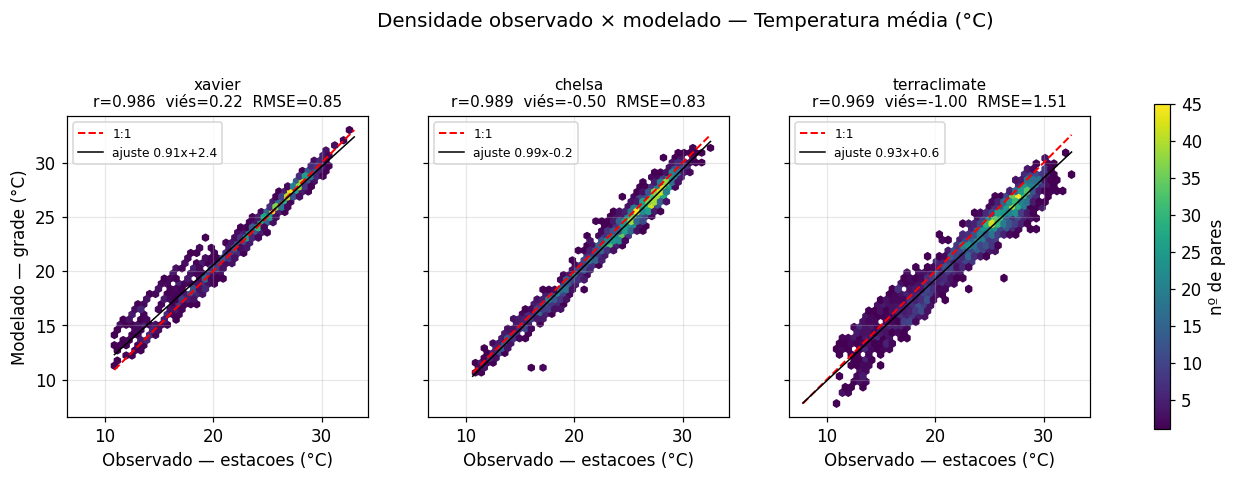

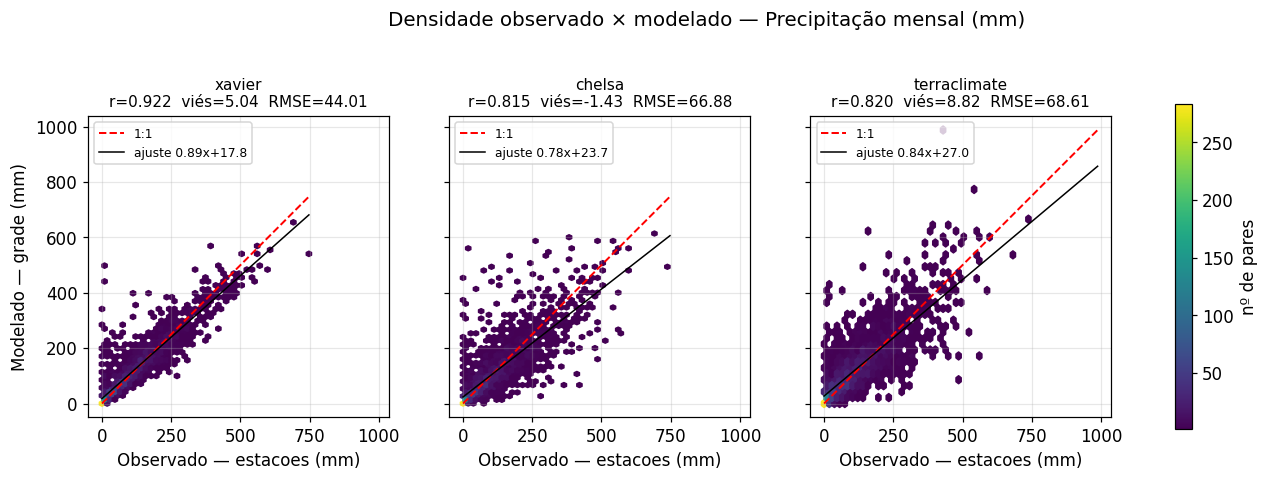

In [ ]:
def plot_densidade(var, base_obs="estacoes"):
    fig, axes = plt.subplots(1, len(REFS), figsize=(5 * len(REFS), 4.8),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes)
    hb = None
    for ax, mod in zip(axes, REFS):
        par = emparelhar(base_obs, mod, var)
        o, m = par[f"{var}_obs"].values, par[f"{var}_mod"].values
        hb = ax.hexbin(o, m, gridsize=40, cmap="viridis", mincnt=1)
        lo, hi = float(min(o.min(), m.min())), float(max(o.max(), m.max()))
        ax.plot([lo, hi], [lo, hi], "r--", lw=1.3, label="1:1")
        a, b = np.polyfit(o, m, 1)
        ax.plot([lo, hi], [a * lo + b, a * hi + b], "k-", lw=1,
                label=f"ajuste {a:.2f}x{b:+.1f}")
        d = _todas_metricas(o, m)
        ax.set_title(f"{mod}\nr={d['r']:.3f}  viés={d['Bias']:.2f}  "
                     f"RMSE={d['RMSE']:.2f}", fontsize=10)
        ax.set_xlabel(f"Observado — {base_obs} ({UNID[var]})")
        ax.set_aspect("equal", "box")
        ax.legend(fontsize=8, loc="upper left")
    axes[0].set_ylabel(f"Modelado — grade ({UNID[var]})")
    fig.colorbar(hb, ax=axes, label="nº de pares", shrink=0.8)
    fig.suptitle(f"Densidade observado × modelado — {NOMES_VAR[var]}",
                 fontsize=13)

for v in ("tmed", "pr_mes"):
    plot_densidade(v)

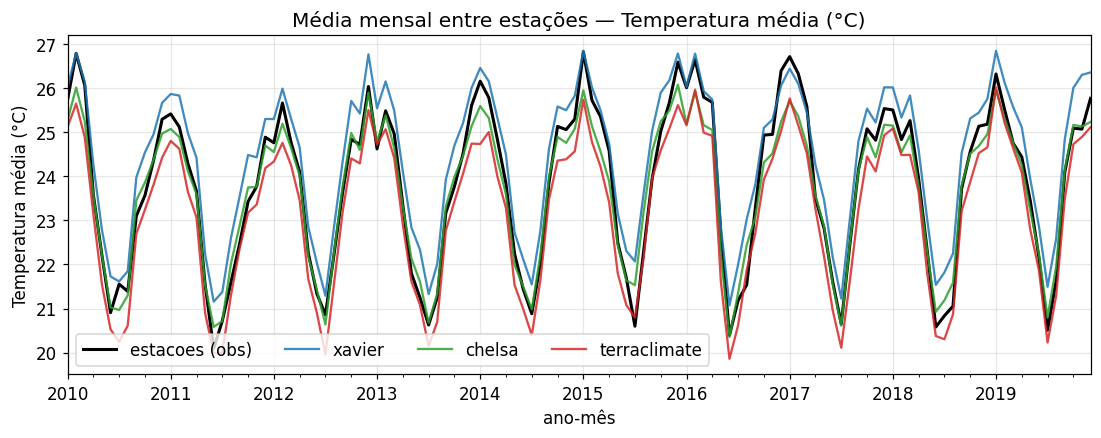

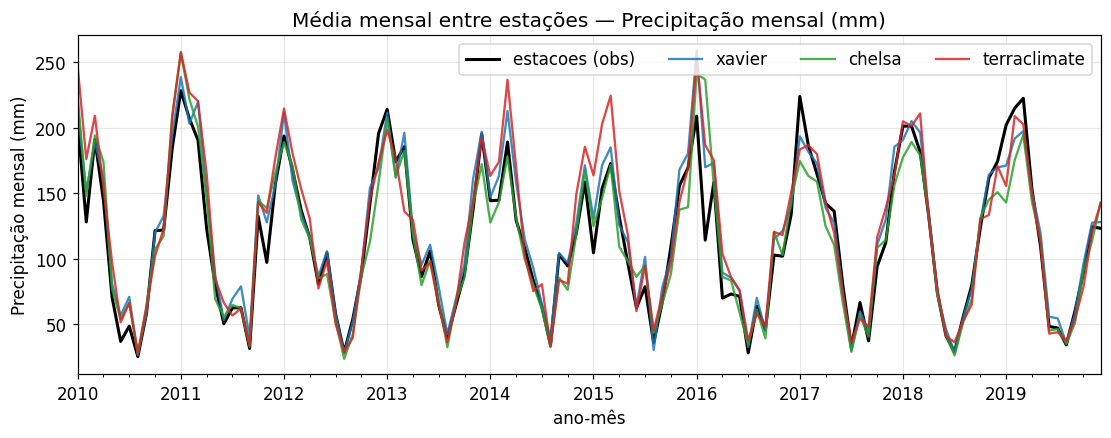

In [ ]:
def plot_serie(var, base_obs="estacoes"):
    obs = PADR_CORTADO[base_obs].groupby("ano_mes")[var].mean()
    fig, ax = plt.subplots(figsize=(12, 4))
    obs.plot(ax=ax, color="black", lw=2, label=f"{base_obs} (obs)")
    for mod in REFS:
        s = PADR_CORTADO[mod].groupby("ano_mes")[var].mean().reindex(obs.index)
        s.plot(ax=ax, color=CORES[mod], alpha=0.85, label=mod)
    ax.set_title(f"Média mensal entre estações — {NOMES_VAR[var]}")
    ax.set_xlabel("ano-mês"); ax.set_ylabel(NOMES_VAR[var])
    ax.legend(ncol=4)

for v in ("tmed", "pr_mes"):
    plot_serie(v)

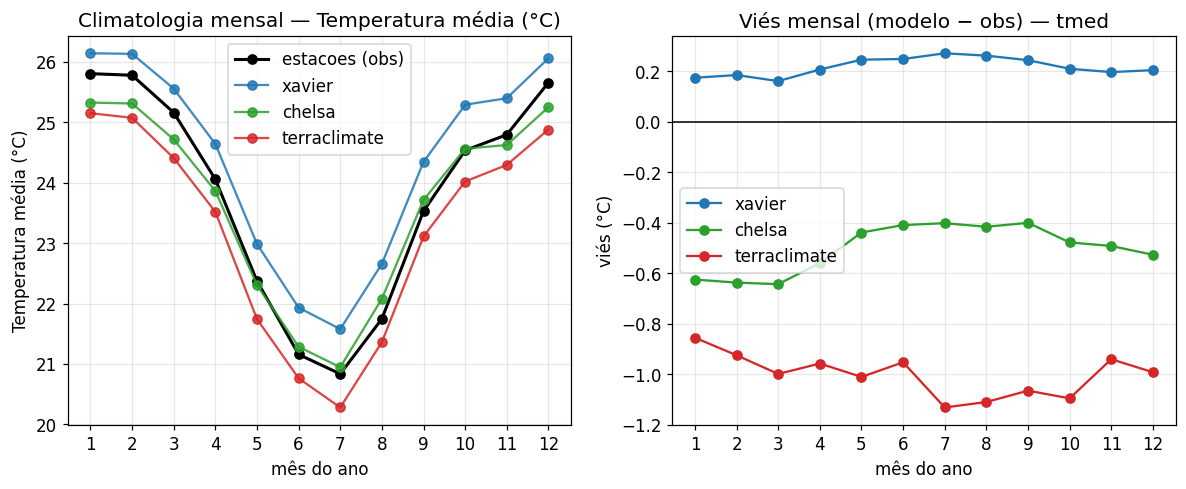

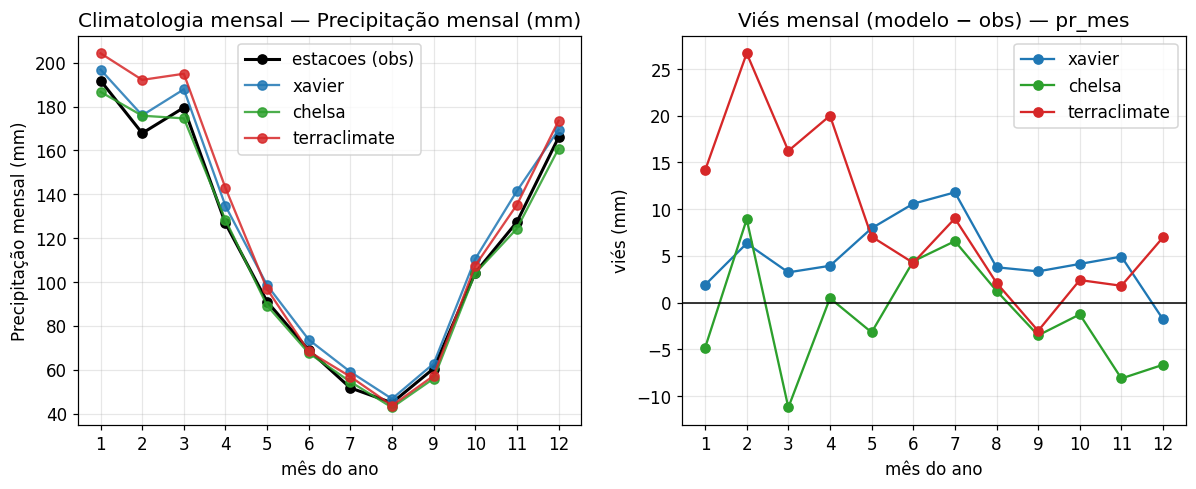

In [ ]:
def plot_ciclo_sazonal(var, base_obs="estacoes"):
    meses = np.arange(1, 13)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))
    clim_obs = PADR_CORTADO[base_obs].groupby("mes")[var].mean().reindex(meses)
    ax1.plot(meses, clim_obs, "ko-", lw=2, label=f"{base_obs} (obs)")
    for mod in REFS:
        clim = PADR_CORTADO[mod].groupby("mes")[var].mean().reindex(meses)
        ax1.plot(meses, clim, "o-", color=CORES[mod], alpha=0.85, label=mod)
        par = emparelhar(base_obs, mod, var)
        par = par.assign(mes=par["ano_mes"].dt.month,
                         dif=par[f"{var}_mod"] - par[f"{var}_obs"])
        vb = par.groupby("mes")["dif"].mean().reindex(meses)
        ax2.plot(meses, vb, "o-", color=CORES[mod], label=mod)
    ax2.axhline(0, color="k", lw=1)
    for ax in (ax1, ax2):
        ax.set_xticks(meses); ax.set_xlabel("mês do ano")
    ax1.set_title(f"Climatologia mensal — {NOMES_VAR[var]}")
    ax1.set_ylabel(NOMES_VAR[var]); ax1.legend()
    ax2.set_title(f"Viés mensal (modelo − obs) — {var}")
    ax2.set_ylabel(f"viés ({UNID[var]})"); ax2.legend()

for v in ("tmed", "pr_mes"):
    plot_ciclo_sazonal(v)

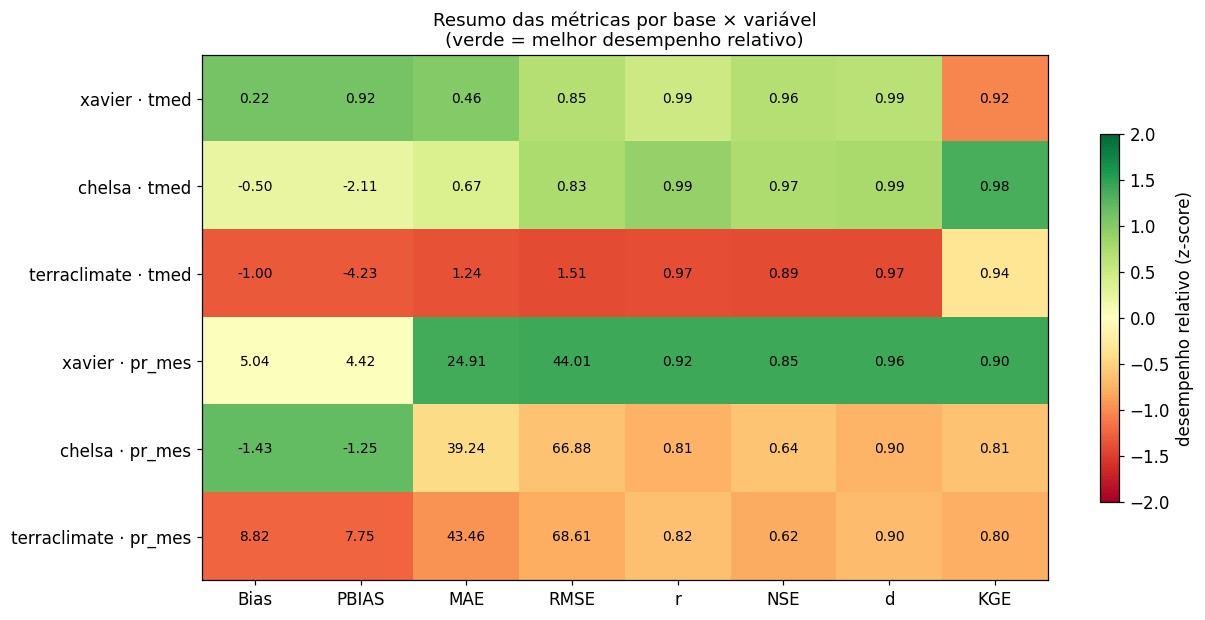

In [ ]:
def plot_heatmap(variaveis=("tmed", "pr_mes")):
    mets = ["Bias", "PBIAS", "MAE", "RMSE", "r", "NSE", "d", "KGE"]
    g = RESUMO_GLOBAL[RESUMO_GLOBAL.variavel.isin(variaveis)].copy()
    g["rotulo"] = g["base"] + " · " + g["variavel"]
    M = g.set_index("rotulo")[mets]
    erros = ["Bias", "PBIAS", "MAE", "RMSE"]
    Z = pd.DataFrame(index=M.index, columns=mets, dtype=float)
    for var in g["variavel"].unique():
        idx = g[g.variavel == var]["rotulo"]
        bloco = M.loc[idx]
        z = (bloco - bloco.mean()) / bloco.std(ddof=0).replace(0, np.nan)
        for col in erros:                      # erro: menor |valor| = melhor
            sd = bloco[col].abs().std(ddof=0)
            z[col] = -(bloco[col].abs() - bloco[col].abs().mean()) / sd \
                if sd else 0.0
        Z.loc[idx] = z
    Z = Z.fillna(0.0)
    fig, ax = plt.subplots(figsize=(1.3 * len(mets) + 2, 0.7 * len(M) + 2))
    im = ax.imshow(Z.values.astype(float), cmap="RdYlGn", aspect="auto",
                   vmin=-2, vmax=2)
    ax.set_xticks(range(len(mets))); ax.set_xticklabels(mets)
    ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index)
    for i in range(len(M)):
        for j, col in enumerate(mets):
            ax.text(j, i, f"{M.iloc[i][col]:.2f}", ha="center", va="center",
                    fontsize=9)
    ax.set_title("Resumo das métricas por base × variável\n"
                 "(verde = melhor desempenho relativo)", fontsize=12)
    fig.colorbar(im, ax=ax, label="desempenho relativo (z-score)", shrink=0.7)
    ax.grid(False)

plot_heatmap()

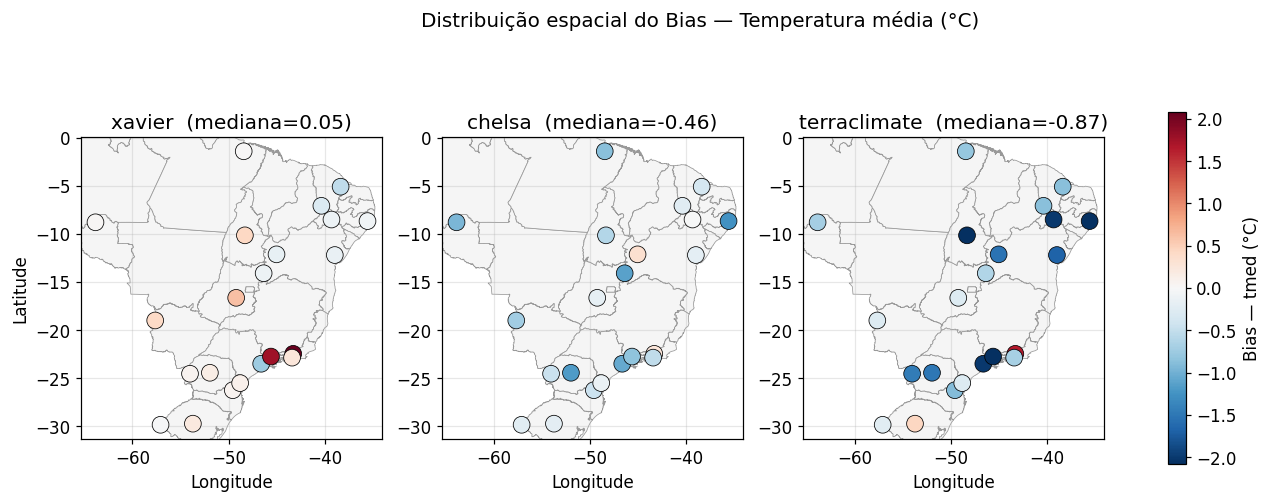

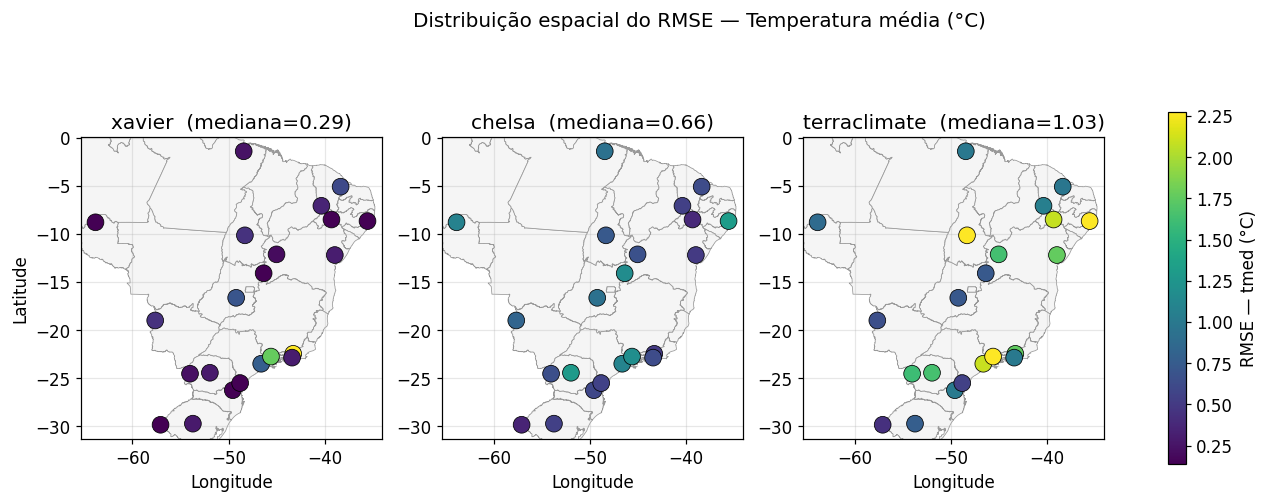

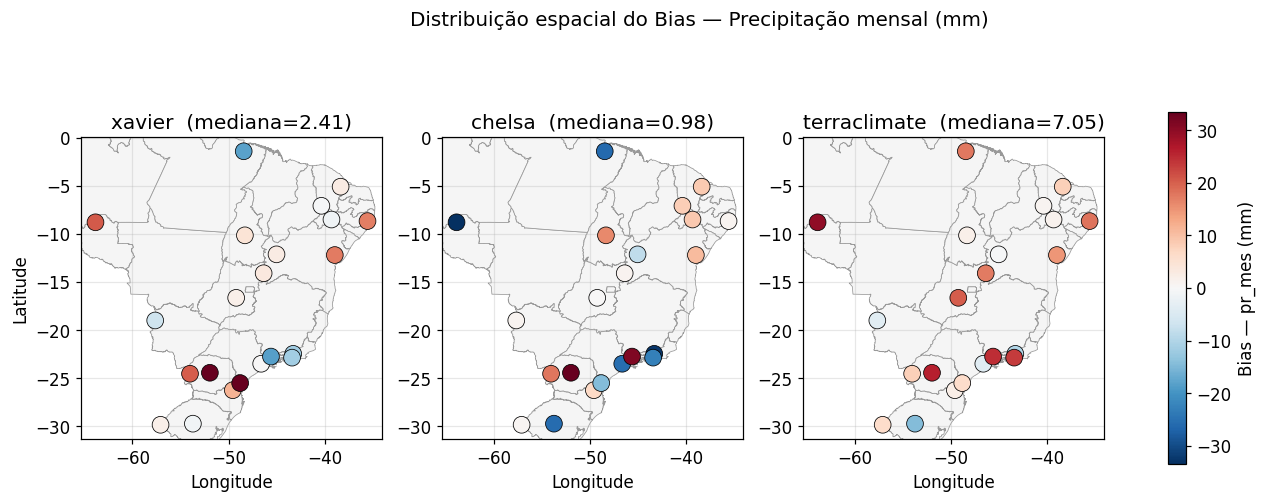

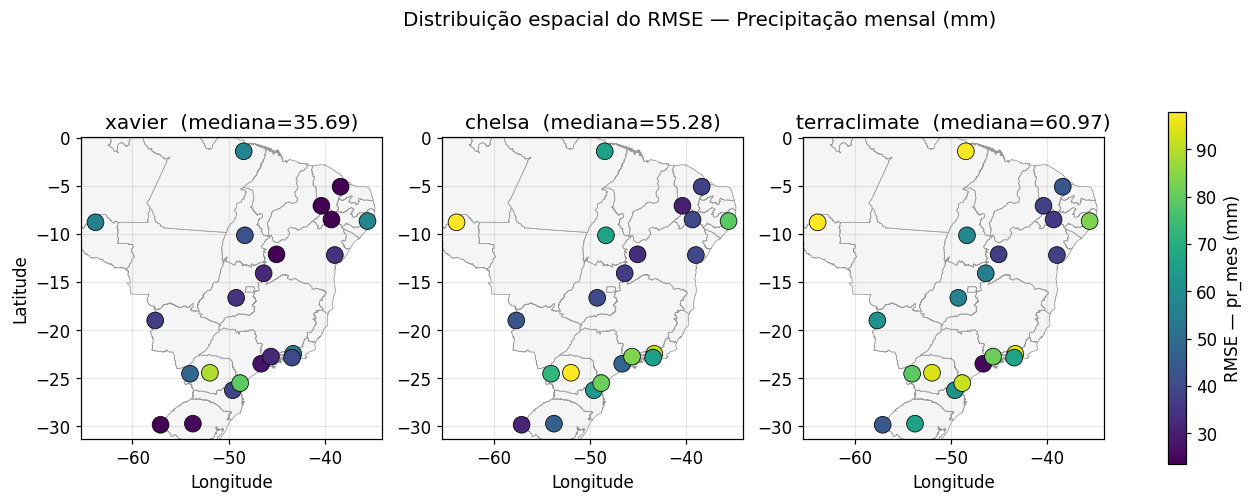

In [ ]:
def carregar_brasil():
    """Devolve um GeoDataFrame com os estados do Brasil para desenhar o
    contorno nos mapas. Instala geopandas no Colab se preciso; se não houver
    internet/biblioteca, devolve None e os mapas saem só com os pontos."""
    try:
        import geopandas as gpd
    except ModuleNotFoundError:
        try:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                            "geopandas"], check=True)
            import geopandas as gpd
        except Exception as e:
            print(f"geopandas indisponível ({e}); mapas sairão sem contorno.")
            return None
    urls = [  # fontes públicas dos limites estaduais (tenta uma a uma)
        "https://raw.githubusercontent.com/codeforamerica/click_that_hood/"
        "master/public/data/brazil-states.geojson",
        "https://raw.githubusercontent.com/giuliano-macedo/"
        "geodata-br-states/main/geojson/br_states.json",
    ]
    for url in urls:
        try:
            return gpd.read_file(url)
        except Exception:
            continue
    print("Não consegui baixar o contorno do Brasil; mapas sem contorno.")
    return None

BRASIL = carregar_brasil()

def plot_mapa(var, metrica="Bias", base_obs="estacoes"):
    if COORD is None:
        print("Sem coordenadas — mapa pulado."); return
    sub = RESUMO_ESTACOES[RESUMO_ESTACOES.variavel == var].dropna(
        subset=["Longitude", "Latitude", metrica])
    if sub.empty:
        print(f"Sem dados p/ mapa {metrica} {var}."); return
    div = metrica in ("Bias", "PBIAS")
    cmap = "RdBu_r" if div else "viridis"
    if div:
        lim = np.nanpercentile(np.abs(sub[metrica]), 95); vmin, vmax = -lim, lim
    else:
        vmin = np.nanpercentile(sub[metrica], 5)
        vmax = np.nanpercentile(sub[metrica], 95)
    xlo, xhi = sub.Longitude.min() - 1.5, sub.Longitude.max() + 1.5
    ylo, yhi = sub.Latitude.min() - 1.5, sub.Latitude.max() + 1.5
    fig, axes = plt.subplots(1, len(REFS), figsize=(5 * len(REFS), 5.2))
    axes = np.atleast_1d(axes); sc = None
    for ax, mod in zip(axes, REFS):
        if BRASIL is not None:                       # contorno dos estados
            BRASIL.plot(ax=ax, facecolor="#f5f5f5", edgecolor="0.6",
                        linewidth=0.5, zorder=0)
        s = sub[sub.base == mod]
        sc = ax.scatter(s.Longitude, s.Latitude, c=s[metrica], cmap=cmap,
                        vmin=vmin, vmax=vmax, s=120, edgecolor="k", lw=0.5,
                        zorder=3)
        ax.set_title(f"{mod}  (mediana={s[metrica].median():.2f})")
        ax.set_xlabel("Longitude")
        ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("Latitude")
    fig.colorbar(sc, ax=axes, label=f"{metrica} — {var} ({UNID[var]})",
                 shrink=0.8)
    fig.suptitle(f"Distribuição espacial do {metrica} — {NOMES_VAR[var]}",
                 fontsize=13)

for v in ("tmed", "pr_mes"):
    plot_mapa(v, "Bias")
    plot_mapa(v, "RMSE")